## Étape — Création de la variable `prep_time_min`

L'objectif de cette étape est de calculer le **temps de préparation de la commande**, c'est-à-dire le temps écoulé entre :

- `Time_Orderd` : heure à laquelle la commande a été passée.
- `Time_Order_picked` : heure à laquelle la commande a été récupérée par le livreur.

### 1. Conversion des heures en datetime

On convertit les deux colonnes en format date/heure avec `pd.to_datetime()` :



In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from geopy.distance import geodesic

file_path = "../data/cleaned_dataset.csv"
df=pd.read_csv(file_path)

diff=pd.to_datetime(df["Time_Order_picked"])-pd.to_datetime(df["Time_Orderd"])

df["prep_time_min"] = (
    diff
).dt.total_seconds() / 60.0

df["prep_time_min"] = df["prep_time_min"].apply(
    lambda x: x + 1440 if x < 0 else x
)
print(df.isnull().sum())

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
prep_time_min                  0
dtype: int64


## Étape — Création des variables temporelles `day_of_week` et `is_weekend`

L'objectif de cette étape est d'extraire des informations utiles à partir de la date de la commande afin d'analyser si le **jour de la semaine** influence le temps de livraison.

### 1. Conversion de `Order_Date` en date


In [96]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['day_of_week'] = df['Order_Date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
print("Features 2 & 3 créées : 'day_of_week' et 'is_weekend'")
print(df['day_of_week'].head())

Features 2 & 3 créées : 'day_of_week' et 'is_weekend'
0    2
1    3
2    6
3    2
4    3
Name: day_of_week, dtype: int32


## Étape — Calcul de la distance entre le restaurant et le client

L'objectif de cette étape est de créer une nouvelle variable `distance_KM` représentant la **distance géographique entre le restaurant et le lieu de livraison**, en kilomètres.

Cette information est importante pour notre modèle car une distance plus grande peut entraîner un temps de livraison plus élevé.

### 1. Création de la fonction de calcul de distance

In [97]:

# def calcule_distance(row):

#         restaurant = (
#             row['Restaurant_latitude'],
#             row['Restaurant_longitude']
#         )

#         client = (
#             row['Delivery_location_latitude'],
#             row['Delivery_location_longitude']
#         )

#         return geodesic(restaurant, client).km
# gps_colmn=['Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude','Delivery_location_longitude']
# df["distance_KM"] = df.apply(calcule_distance, axis=1)
# print(df["distance_KM"].head(5))
import numpy as np
def haversine_vectorized(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c
    return km
df['distance_km'] = haversine_vectorized(
    df['Restaurant_latitude'],
    df['Restaurant_longitude'],
    df['Delivery_location_latitude'],
    df['Delivery_location_longitude']
)
print(df[['Restaurant_latitude', 'Delivery_location_latitude', 'distance_km']].head())

   Restaurant_latitude  Delivery_location_latitude  distance_km
0            27.163303                   27.233303    10.416964
1            27.163303                   27.203303     5.952905
2            27.163303                   27.203303     5.952905
3            27.163303                   27.273303    16.368216
4            27.163303                   27.173303     1.488315


In [98]:
num_cols = df.select_dtypes(include=[np.number]).columns

# Calcul des statistiques descriptives
stats_numeriques = df[num_cols].agg(['mean', 'median', 'std', 'min', 'max']).T

# Renommer les colonnes pour un affichage propre
stats_numeriques.columns = ['Moyenne', 'Médiane', 'Écart-type', 'Minimum', 'Maximum']

print("📊 --- STATISTIQUES DESCRIPTIVES (VARIABLES NUMÉRIQUES) ---")
display(stats_numeriques.round(2))

📊 --- STATISTIQUES DESCRIPTIVES (VARIABLES NUMÉRIQUES) ---


,Moyenne,Médiane,Écart-type,Minimum,Maximum
Delivery_person_Age,29.56,30.00,5.75,20.00,39.00
Delivery_person_Ratings,4.64,4.70,0.31,2.50,5.00
Restaurant_latitude,18.92,19.07,5.25,9.96,30.91
Restaurant_longitude,76.89,76.62,3.36,72.77,88.43
Delivery_location_latitude,18.99,19.13,5.25,9.97,31.05
Delivery_location_longitude,76.96,76.66,3.36,72.78,88.56
Vehicle_condition,1.00,1.00,0.82,0.00,2.00
multiple_deliveries,0.75,1.00,0.57,0.00,3.00
Time_taken(min),26.29,26.00,9.37,10.00,54.00
prep_time_min,9.99,10.00,4.09,5.00,15.00


In [99]:
# Sélection automatique des colonnes catégorielles / textuelles
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print("📋 --- DISTRIBUTION DES FRÉQUENCES (VARIABLES CATÉGORIELLES) ---")

for col in cat_cols:
    print(f"\n🔹 Variable : {col}")
    
    # Création du tableau de fréquences
    freq_abs = df[col].value_counts(dropna=False)
    freq_rel = df[col].value_counts(normalize=True, dropna=False) * 100
    
    df_freq = pd.DataFrame({
        'Effectif (Nombre)': freq_abs,
        'Fréquence (%)': freq_rel.round(2)
    })
    
    display(df_freq)

📋 --- DISTRIBUTION DES FRÉQUENCES (VARIABLES CATÉGORIELLES) ---

🔹 Variable : ID


/tmp/ipykernel_1357542/293437198.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns


,Effectif (Nombre),Fréquence (%)
ID,,
0xc042,1,0.0
0xc3ec,1,0.0
0xc58f,1,0.0
0xccee,1,0.0
0xcff4,1,0.0
...,...,...
0xb38,1,0.0
0xbeab,1,0.0
0xc97,1,0.0



🔹 Variable : Delivery_person_ID


,Effectif (Nombre),Fréquence (%)
Delivery_person_ID,,
JAPRES09DEL02,65,0.15
JAPRES11DEL02,65,0.15
PUNERES01DEL01,65,0.15
VADRES11DEL02,65,0.15
INDORES08DEL02,64,0.15
...,...,...
BHPRES15DEL03,6,0.01
GOARES01DEL03,6,0.01
KOCRES16DEL03,6,0.01


...

,Effectif (Nombre),Fréquence (%)
Type_of_vehicle,,
motorcycle,25633,58.44
scooter,14695,33.50
electric_scooter,3534,8.06



🔹 Variable : Festival


,Effectif (Nombre),Fréquence (%)
Festival,,
No,43005,98.05
Yes,857,1.95



🔹 Variable : City


,Effectif (Nombre),Fréquence (%)
City,,
Metropolitian,33946,77.39
Urban,9760,22.25
Semi-Urban,156,0.36


### 📊 Interprétation de la distribution du temps de livraison (`Time_taken(min)`)

L'analyse de l'histogramme et de la courbe de densité (KDE) de la variable cible révèle plusieurs caractéristiques importantes :

* **Tendance centrale et valeurs extrêmes :**
  * **Médiane :** $26.00\text{ min}$
  * **Moyenne :** $26.30\text{ min}$
  * La proximité quasi-parfaite entre la moyenne et la médiane (seulement 0.30 min d'écart) indique l'**absence de valeurs aberrantes ou extrêmes** susceptibles de fausser les statistiques centrales, confirmant l'efficacité de la phase de nettoyage préalable.
C
* **Multimodalité :**
  * La présence de plusieurs pics distincts (notamment autour de 18 min, 25 min et 29 min) suggère que la population globale de livraison est composée de **sous-groupes distincts** (par exemple, selon la densité du trafic, le type de véhicule ou les tranches de distance).

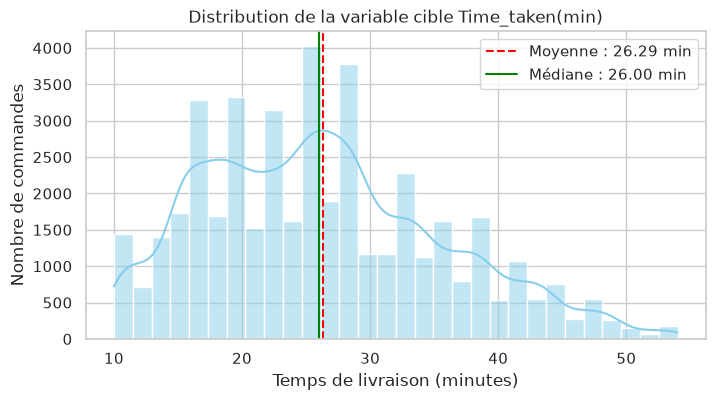

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(df['Time_taken(min)'], kde=True, bins=30, color='skyblue')

# Ajouter les lignes de la moyenne et de la médiane
plt.axvline(df['Time_taken(min)'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['Time_taken(min)'].mean():.2f} min")
plt.axvline(df['Time_taken(min)'].median(), color='green', linestyle='-', label=f"Médiane : {df['Time_taken(min)'].median():.2f} min")

plt.title("Distribution de la variable cible Time_taken(min)")
plt.xlabel("Temps de livraison (minutes)")
plt.ylabel("Nombre de commandes")
plt.legend()
plt.show()

### 📊 Analyse de l'impact de `distance_KM` sur `Time_taken(min)`

L'observation du nuage de points révèle deux informations essentielles :

1. **Structure des données (Effet de grille) :** 
   Les points s'organisent sous forme de bandes verticales distinctes. Cela indique que les coordonnées GPS source possèdent un niveau d'arrondi ou de discrétisation préexistant dans le dataset.

2. **Absence de relation linéaire directe :** 
   Pour n'importe quelle tranche de distance (de 1.5 km à 20 km), les temps de livraison couvrent la quasi-totalité du spectre (de 10 à 50 minutes). La distance seule ne suffit donc pas à expliquer le délai de livraison.

**Conclusion :** Des variables contextuelles telles que le trafic routier (`Road_traffic_density`), les conditions météo et le temps de préparation en cuisine jouent un rôle prépondérant par rapport à la simple distance géographique.

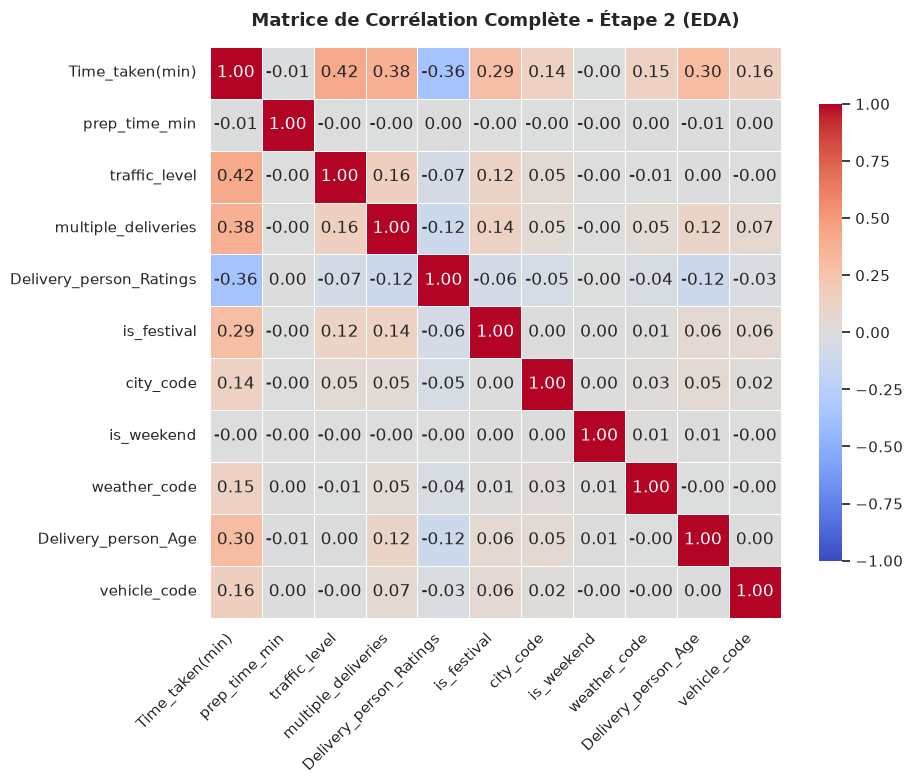

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Copie temporaire du DataFrame pour l'étape de corrélation
df_corr = df.copy()

# 2. Conversion des variables catégorielles clés en nombres (pour inclusion dans la matrice)
if 'Road_traffic_density' in df_corr.columns:
    df_corr['traffic_level'] = df_corr['Road_traffic_density'].map({'Low': 1, 'Medium': 2, 'High': 3, 'Jam': 4})



if 'Festival' in df_corr.columns:
    df_corr['is_festival'] = df_corr['Festival'].map({'No': 0, 'Yes': 1})
if 'is_weekend' in df_corr.columns:
    # On remplace les NaN éventuels par 0, puis on convertit en type entier (int)
    df_corr['is_weekend'] = df_corr['is_weekend'].fillna(0).astype(int)
if 'City' in df_corr.columns:
    # 0 = Semi-Urban, 1 = Urban, 2 = Metropolitian (selon la densité)
    city_map = {'Semi-Urban': 0, 'Urban': 1, 'Metropolitian': 2}
    df_corr['city_code'] = df_corr['City'].map(city_map)
    


# 3. Liste des variables numériques clés à inclure dans la matrice
# Nettoyage des espaces blancs parasites (' Sunny' -> 'Sunny')
if 'Weatherconditions' in df_corr.columns:
    df_corr['Weatherconditions'] = df_corr['Weatherconditions'].astype(str).str.strip()
    
    # Mapping numérique des conditions météo
    weather_map = {
        'Sunny': 1, 
        'ClOUDY': 2, 
        'Windy': 3, 
        'Fog': 4, 
        'Stormy': 5, 
        'Sandstorms': 6
    }
    df_corr['weather_code'] = df_corr['Weatherconditions'].map(weather_map)
    if 'Type_of_vehicle' in df_corr.columns:
        vehicle_map = {'scooter': 1, 'electric_scooter': 2, 'motorcycle': 3, 'bicycle': 4}
    df_corr['vehicle_code'] = df_corr['Type_of_vehicle'].astype(str).str.strip().map(vehicle_map)

# Assurez-vous d'utiliser 'weather_code' (numérique) et non 'Weatherconditions' (texte)
cols_to_correlate = [
    'Time_taken(min)', 
    'distance_KM', 
    'prep_time_min', 
    'traffic_level',
    'multiple_deliveries', 
    'Delivery_person_Ratings',
    'is_festival',
    'city_code',
    'is_weekend',
    'weather_code',
    'Delivery_person_Age',
    'vehicle_code'# Utiliser la version numérique !
]

valid_cols = [c for c in cols_to_correlate if c in df_corr.columns]

# Calcul sécurisé de la corrélation
corr_matrix = df_corr[valid_cols].corr(numeric_only=True)


plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    annot=True,                
    fmt=".2f",                  
    cmap="coolwarm",           
    vmin=-1, vmax=1,           
    linewidths=0.5,             
    cbar_kws={"shrink": 0.8},  
    square=True                
)

plt.title("Matrice de Corrélation Complète - Étape 2 (EDA)", fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

a médiane du temps de livraison augmente avec le niveau de trafic. Les livraisons effectuées dans des conditions de trafic plus importantes ont donc tendance à prendre plus de temps.

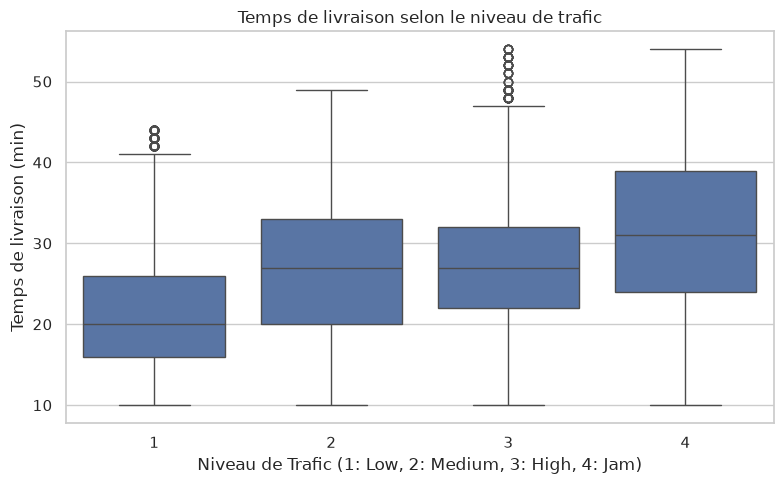

In [102]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_corr,
    x='traffic_level',
    y='Time_taken(min)'
)

plt.title("Temps de livraison selon le niveau de trafic")
plt.xlabel("Niveau de Trafic (1: Low, 2: Medium, 3: High, 4: Jam)")
plt.ylabel("Temps de livraison (min)")

plt.tight_layout()
plt.show()



a médiane du temps de livraison augmente avec le niveau de NOmbre de livraison. Les livraisons effectuées dans des nombre des commande importantes ont donc tendance à prendre plus de temps.


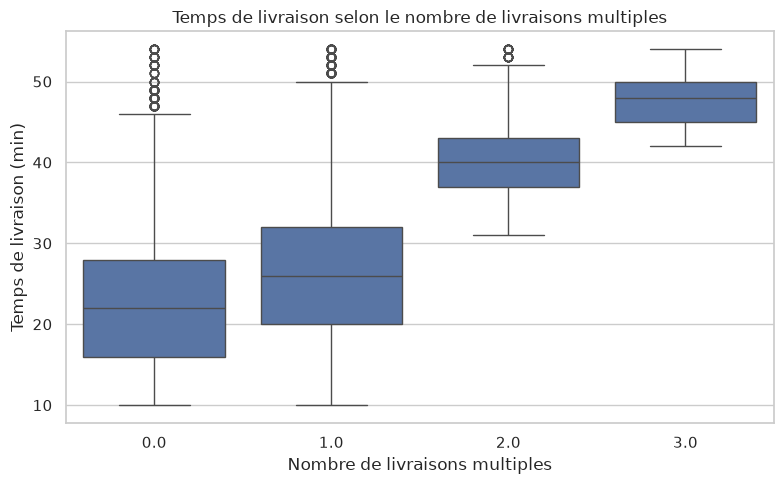

In [103]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_corr,
    x='multiple_deliveries',
    y='Time_taken(min)'
)

plt.title("Temps de livraison selon le nombre de livraisons multiples")
plt.xlabel("Nombre de livraisons multiples")
plt.ylabel("Temps de livraison (min)")

plt.tight_layout()
plt.show()

Le nuage de points montre une forte dispersion des observations et une tendance positive relativement faible entre l'âge du livreur et le temps de livraison

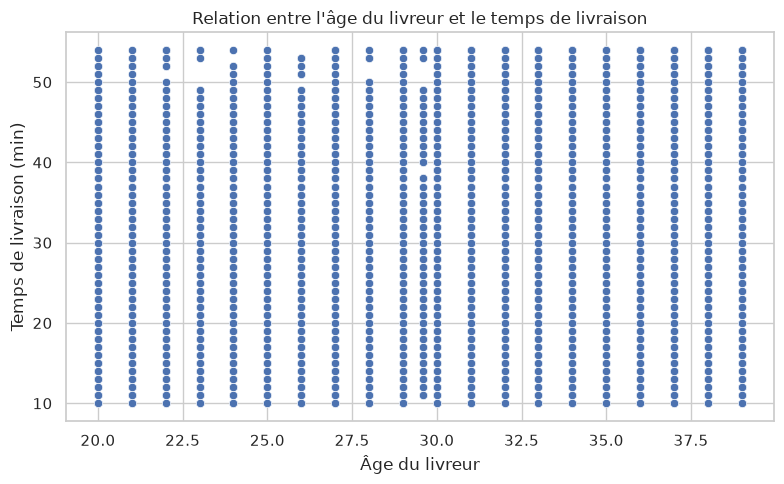

In [104]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_corr,
    x='Delivery_person_Age',
    y='Time_taken(min)'
)

plt.title("Relation entre l'âge du livreur et le temps de livraison")
plt.xlabel("Âge du livreur")
plt.ylabel("Temps de livraison (min)")

plt.tight_layout()
plt.show()

In [105]:
corr_target = df_corr.corr(numeric_only=True)['Time_taken(min)']

print(corr_target.sort_values(ascending=False))

Time_taken(min)                1.000000
traffic_level                  0.417048
multiple_deliveries            0.379204
distance_km                    0.306455
Delivery_person_Age            0.302988
is_festival                    0.289269
vehicle_code                   0.158513
weather_code                   0.146699
city_code                      0.140804
Delivery_location_latitude     0.013756
Delivery_location_longitude    0.012180
Restaurant_latitude            0.011683
Restaurant_longitude           0.008944
day_of_week                    0.006505
is_weekend                    -0.003131
prep_time_min                 -0.008478
Vehicle_condition             -0.243111
Delivery_person_Ratings       -0.359811
Name: Time_taken(min), dtype: float64


Le scatterplot montre que les distances sont regroupées en plusieurs valeurs discrètes, ce qui forme des bandes verticales. On observe une forte dispersion du temps de livraison pour une même distance. La distance présente néanmoins une corrélation positive modérée avec le temps de livraison (r ≈ 0,32), ce qui indique qu'elle est associée au temps, mais qu'elle ne suffit pas à expliquer seule sa variation. D'autres facteurs, notamment le trafic et les livraisons multiples, peuvent également contribuer à cette variation.

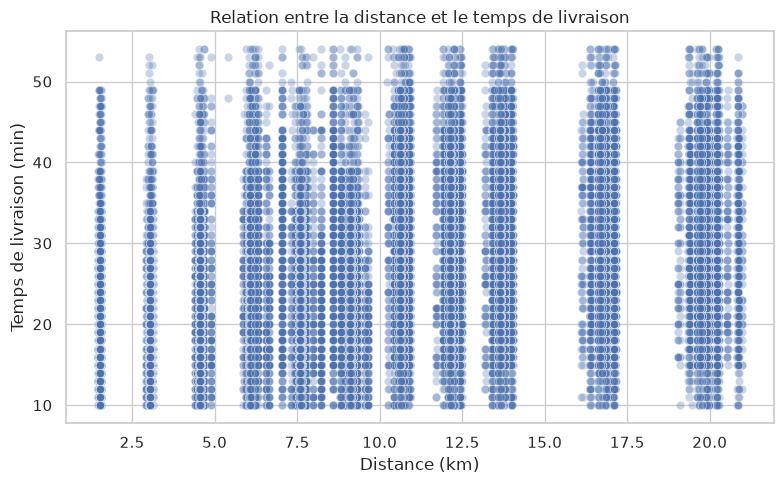

In [106]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_corr,
    x='distance_km',
    y='Time_taken(min)',
    alpha=0.3
)

plt.title("Relation entre la distance et le temps de livraison")
plt.xlabel("Distance (km)")
plt.ylabel("Temps de livraison (min)")

plt.tight_layout()
plt.show()

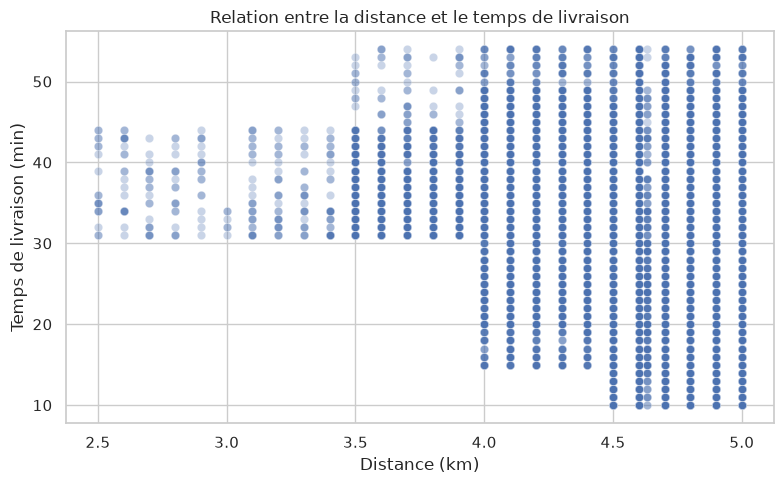

In [107]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_corr,
    x='Delivery_person_Ratings',
    y='Time_taken(min)',
    alpha=0.3
)

plt.title("Relation entre la distance et le temps de livraison")
plt.xlabel("Distance (km)")
plt.ylabel("Temps de livraison (min)")

plt.tight_layout()
plt.show()

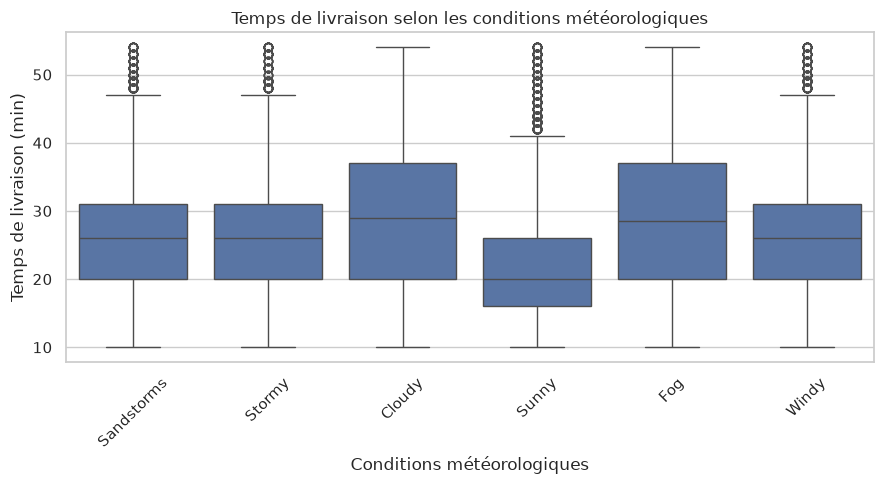

In [108]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_corr,
    x='Weatherconditions',
    y='Time_taken(min)'
)

plt.title("Temps de livraison selon les conditions météorologiques")
plt.xlabel("Conditions météorologiques")
plt.ylabel("Temps de livraison (min)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

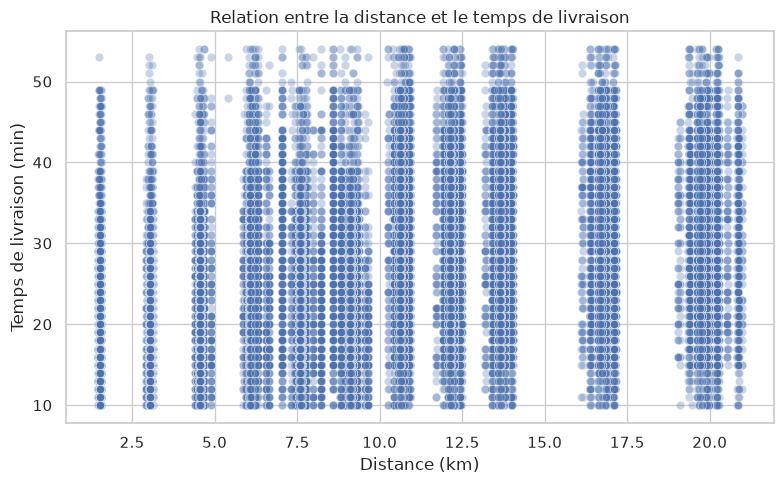

In [109]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_corr,
    x='distance_km',
    y='Time_taken(min)',
    alpha=0.3
)

plt.title("Relation entre la distance et le temps de livraison")
plt.xlabel("Distance (km)")
plt.ylabel("Temps de livraison (min)")

plt.tight_layout()
plt.show()

In [110]:
Q1 = df_corr['Time_taken(min)'].quantile(0.25)
Q3 = df_corr['Time_taken(min)'].quantile(0.75)

IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

outliers = df_corr[
    (df_corr['Time_taken(min)'] < borne_inf) |
    (df_corr['Time_taken(min)'] > borne_sup)
]

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Borne inférieure :", borne_inf)
print("Borne supérieure :", borne_sup)
print("Nombre d'outliers :", len(outliers))

Q1 : 19.0
Q3 : 32.0
IQR : 13.0
Borne inférieure : -0.5
Borne supérieure : 51.5
Nombre d'outliers : 255


In [111]:

df = df.drop(columns=[
    'ID',
    'Delivery_person_ID',
    'Restaurant_latitude',
    'Restaurant_longitude',
    'Delivery_location_latitude',
    'Delivery_location_longitude'
])

In [115]:
features=['Time_taken(min)','distance_km', 'prep_time_min','Road_traffic_density','multiple_deliveries','Delivery_person_Age','Weatherconditions','Delivery_person_Ratings','City','Festival','Type_of_vehicle']
df_features = df[features].copy()
df_features.to_csv('../data/features_data.csv', index=False)
print(df.isna().sum())

Delivery_person_Age        0
Delivery_person_Ratings    0
Order_Date                 0
Time_Orderd                0
Time_Order_picked          0
Weatherconditions          0
Road_traffic_density       0
Vehicle_condition          0
Type_of_order              0
Type_of_vehicle            0
multiple_deliveries        0
Festival                   0
City                       0
Time_taken(min)            0
prep_time_min              0
day_of_week                0
is_weekend                 0
distance_km                0
dtype: int64
